<a href="https://colab.research.google.com/github/esinghbe23-ctrl/Deep-Learning-Assignments/blob/main/ASS_3(DL_without_inbuilt_func_).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [10]:

from google.colab import files
import pandas as pd
import numpy as np
uploaded = files.upload()
df = pd.read_csv('multiple_linear_regression_dataset.csv')
print(df.head())

Saving multiple_linear_regression_dataset.csv to multiple_linear_regression_dataset (2).csv
   age  experience  income
0   25           1   30450
1   30           3   35670
2   47           2   31580
3   32           5   40130
4   43          10   47830


In [11]:
X = df[['age', 'experience']].values
y = df['income'].values.reshape(-1, 1)
X_b = np.hstack([np.ones((X.shape[0], 1)), X])
np.random.seed(42)
indices = np.arange(X_b.shape[0])
np.random.shuffle(indices)

train_size = int(0.8 * len(indices))
train_idx = indices[:train_size]
test_idx = indices[train_size:]

X_train, X_test = X_b[train_idx], X_b[test_idx]
y_train, y_test = y[train_idx], y[test_idx]
theta = np.linalg.inv(X_train.T @ X_train) @ X_train.T @ y_train
y_pred = X_test @ theta
def r2_score_manual(y_true, y_pred):
    ss_res = np.sum((y_true - y_pred) ** 2)
    ss_tot = np.sum((y_true - np.mean(y_true)) ** 2)
    return 1 - ss_res / ss_tot

def mean_squared_error_manual(y_true, y_pred):
    return np.mean((y_true - y_pred) ** 2)

r2 = r2_score_manual(y_test, y_pred)
mse = mean_squared_error_manual(y_test, y_pred)
accuracy = r2 * 100

print("R2 Score:", r2)
print("Model Accuracy (%):", accuracy)
print("Mean Squared Error:", mse)
print("Intercept:", theta[0][0])
print("Coefficients:", theta[1:].flatten())

R2 Score: 0.9460283960943875
Model Accuracy (%): 94.60283960943875
Mean Squared Error: 3804990.9915726716
Intercept: 31118.150300614918
Coefficients: [ -91.86306325 2149.28778307]


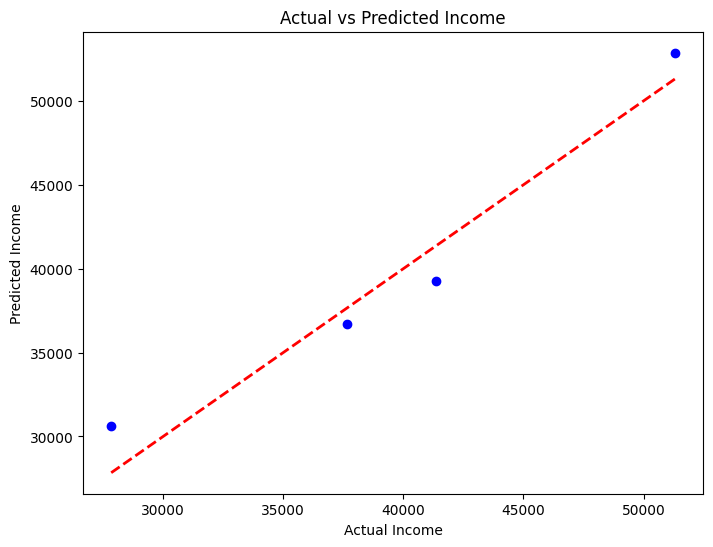

In [12]:
import matplotlib.pyplot as plt
plt.figure(figsize=(8,6))
plt.scatter(y_test, y_pred, color='blue')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', linewidth=2)
plt.xlabel('Actual Income')
plt.ylabel('Predicted Income')
plt.title('Actual vs Predicted Income')
plt.show()

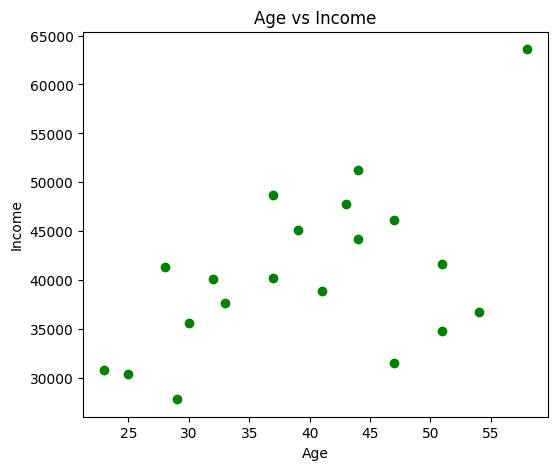

In [ ]:
plt.figure(figsize=(6,5))
plt.scatter(df['age'], df['income'], color='green')
plt.xlabel("Age")
plt.ylabel("Income")
plt.title("Age vs Income")
plt.show()

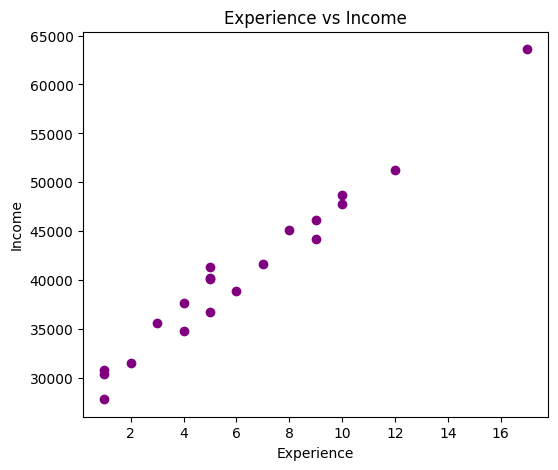

In [ ]:
plt.figure(figsize=(6,5))
plt.scatter(df['experience'], df['income'], color='purple')
plt.xlabel("Experience")
plt.ylabel("Income")
plt.title("Experience vs Income")
plt.show()